In [2]:
import pandas as pd
df = pd.read_csv("/Users/samreddyvarunreddy/Downloads/Grocery_Items_12.csv")
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,whole milk,soda,other vegetables,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,butter,soda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,beef,soda,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,chocolate,curd,shopping bags,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,zwieback,yogurt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
num_records = len(df)
num_records

8000

In [4]:

transactions = df.apply(lambda row: row.dropna().tolist(), axis=1)
all_items = [item for sublist in transactions for item in sublist]
unique_items = set(all_items)
num_unique_items = len(unique_items)
item_counts = pd.Series(all_items).value_counts()
most_popular_item = item_counts.index[0]
most_popular_count = item_counts.iloc[0]
num_records, num_unique_items, most_popular_item, most_popular_count

(8000, 165, 'whole milk', 1328)

1C.
Number of records: 8000
Number of unique items: 165
Most popular item: whole milk
Number of transactions containing popular item(Whole milk): 1328

In [5]:
!pip install mlxtend

In [6]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_te, min_support=0.01, use_colnames=True)

rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.08)

rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(rolls/buns),(other vegetables),0.108375,0.123750,0.010125,0.093426,0.754954,1.0,-0.003286,0.966551,-0.266881,0.045608,-0.034607,0.087622
1,(other vegetables),(rolls/buns),0.123750,0.108375,0.010125,0.081818,0.754954,1.0,-0.003286,0.971077,-0.270298,0.045608,-0.029785,0.087622
2,(soda),(other vegetables),0.094500,0.123750,0.010250,0.108466,0.876490,1.0,-0.001444,0.982856,-0.134664,0.049279,-0.017443,0.095647
3,(other vegetables),(soda),0.123750,0.094500,0.010250,0.082828,0.876490,1.0,-0.001444,0.987274,-0.138537,0.049279,-0.012890,0.095647
4,(other vegetables),(whole milk),0.123750,0.155500,0.015625,0.126263,0.811978,1.0,-0.003618,0.966538,-0.209025,0.059270,-0.034621,0.113372
5,(whole milk),(other vegetables),0.155500,0.123750,0.015625,0.100482,0.811978,1.0,-0.003618,0.974133,-0.215192,0.059270,-0.026554,0.113372
6,(rolls/buns),(whole milk),0.108375,0.155500,0.012375,0.114187,0.734321,1.0,-0.004477,0.953361,-0.288651,0.049205,-0.048920,0.096884
7,(soda),(whole milk),0.094500,0.155500,0.011750,0.124339,0.799605,1.0,-0.002945,0.964414,-0.216775,0.049318,-0.036899,0.099951
8,(yogurt),(whole milk),0.082000,0.155500,0.010375,0.126524,0.813662,1.0,-0.002376,0.966827,-0.199660,0.045680,-0.034311,0.096622


In [7]:
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
0,(rolls/buns),(other vegetables),0.010125,0.093426,0.754954
1,(other vegetables),(rolls/buns),0.010125,0.081818,0.754954
2,(soda),(other vegetables),0.010250,0.108466,0.876490
3,(other vegetables),(soda),0.010250,0.082828,0.876490
4,(other vegetables),(whole milk),0.015625,0.126263,0.811978
5,(whole milk),(other vegetables),0.015625,0.100482,0.811978
6,(rolls/buns),(whole milk),0.012375,0.114187,0.734321
7,(soda),(whole milk),0.011750,0.124339,0.799605
8,(yogurt),(whole milk),0.010375,0.126524,0.813662


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
supports = [0.001, 0.005, 0.01]
confidences = [0.05, 0.075, 0.1]
results = pd.DataFrame(index=confidences, columns=supports)
for supp in supports:
    frequent_itemsets = apriori(df_te, min_support=supp, use_colnames=True)
    for conf in confidences:
        rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
        results.loc[conf, supp] = len(rules)

results = results.astype(int)


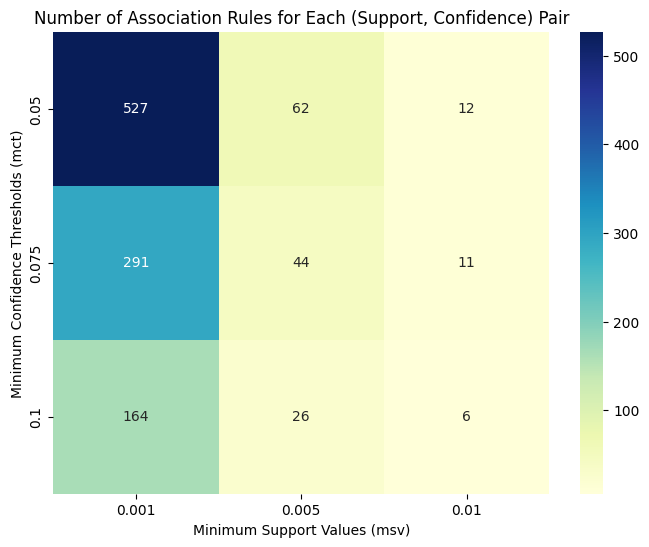

,0.001,0.005,0.010
0.050,527,62,12
0.075,291,44,11
0.100,164,26,6


In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(results, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Number of Association Rules for Each (Support, Confidence) Pair")
plt.xlabel("Minimum Support Values (msv)")
plt.ylabel("Minimum Confidence Thresholds (mct)")
plt.show()
results

The largest number of rules appears at lowest support and lowest confidence (0.001, 0.05).
The smallest number of rules appears at highest support and highest confidence (0.01, 0.1).
